# 🚀 Guía de Deployment - Lambda loader (ETL)

Esta guía te llevará paso a paso por el despliegue de la función Lambda que procesa y carga datos de RAWG en PostgreSQL RDS.

## 📋 Tabla de Contenidos

1. [Pre-requisitos](#pre-requisitos)
2. [Preparar el código](#preparar-el-código)
3. [Crear la función Lambda](#crear-la-función-lambda)
4. [Configurar Lambda Layers](#configurar-lambda-layers)
5. [Añadir trigger S3](#añadir-trigger-s3)
6. [Configurar permisos](#configurar-permisos)
7. [Probar la función](#probar-la-función)
8. [Monitorear ejecuciones](#monitorear-ejecuciones)


## 🔧 Pre-requisitos

Antes de comenzar, asegúrate de tener:

- ✅ Cuenta AWS con acceso a:
  - Lambda
  - S3
  - RDS PostgreSQL
  - Secrets Manager
  - IAM
  - CloudWatch Logs

-  Servicios ya creados:
  - Bucket S3: `project-api-load-rawg-cris`
  - RDS PostgreSQL con esquema `rawg` creado
  - Secreto en Secrets Manager: `Postgre` con credenciales de RDS

- Código preparado:
  - `lambda_function.py`
  - `transform_rawg.py`
  - `utils/aws_secrets.py`


##  1. Preparar el código

### **1.1 Estructura del paquete**
```
lambda-loader.zip/
├── lambda_loader.py         # Handler principal
├── transform_rawg.py        # Script de transformación
├── asn1crypto/
├── asn1crypto-1.5.1.dist-info/
├── dateutil/ 
├── pg8000/
├── pg8000-1.31.5.dist-info/
├── python_dateutil-2.9.0.post0.dist-info/
├── scramp
├── scramp-1.4.8.dist-info/
├── six-1.17.0.dist-info/
└── utils/
|    └── aws_secrets.py      # Helper de Secrets Manager
├── scramp
├── scramp


### **1.2 Crear el ZIP**

**En Windows (PowerShell)**
```powershell
# Ir al directorio del proyecto
cd C:\Users\crisr\dev\rawg-aws-ml-analytics

# Crear directorio temporal
mkdir lambda_loader_package
cd lambda_loader_package

# Copiar archivos
Copy-Item ..\lambda\lambda_loader.py .
Copy-Item ..\01_etl\transform_rawg.py .
Copy-Item -Recurse ..\utils .

# Crear ZIP
Compress-Archive -Path * -DestinationPath lambda-loader.zip
```


✅ **Resultado:** Archivo `lambda_loader.zip` (~50-100 KB)


## 🔨 2. Crear la función Lambda

### **2.1 Acceder a Lambda Console**

1. Ir a [AWS Lambda Console](https://console.aws.amazon.com/lambda/)
2. Click en **"Create function"** (Crear función)

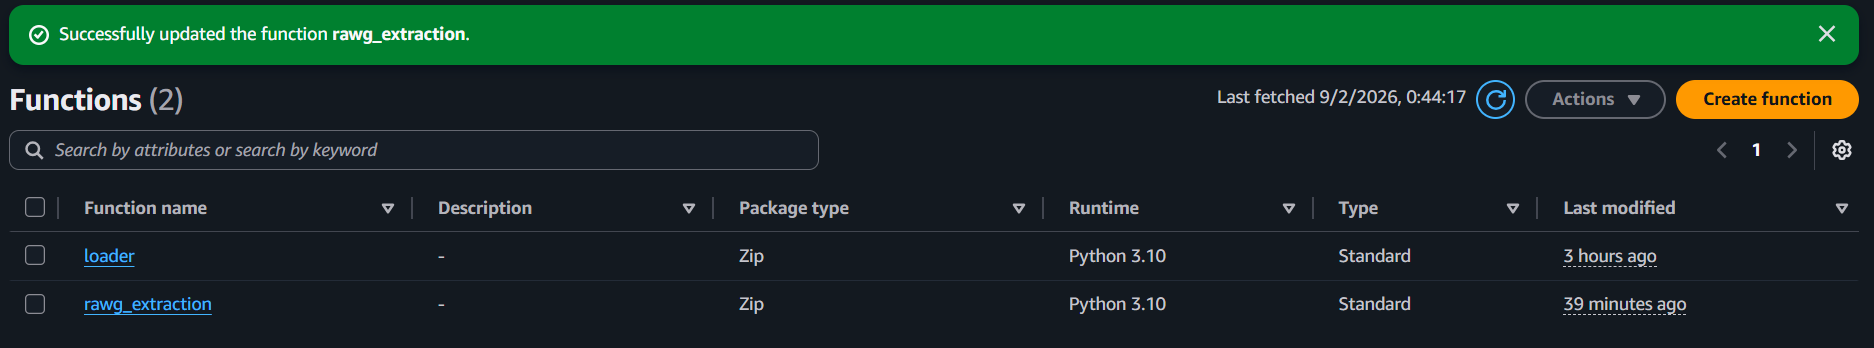

### **2.2 Configuración básica**

| Campo | Valor |
|-------|-------|
| **Function name** | `loader` |
| **Runtime** | Python 3.10 |
| **Architecture** | x86_64 |
| **Execution role** | Create a new role with basic Lambda permissions |

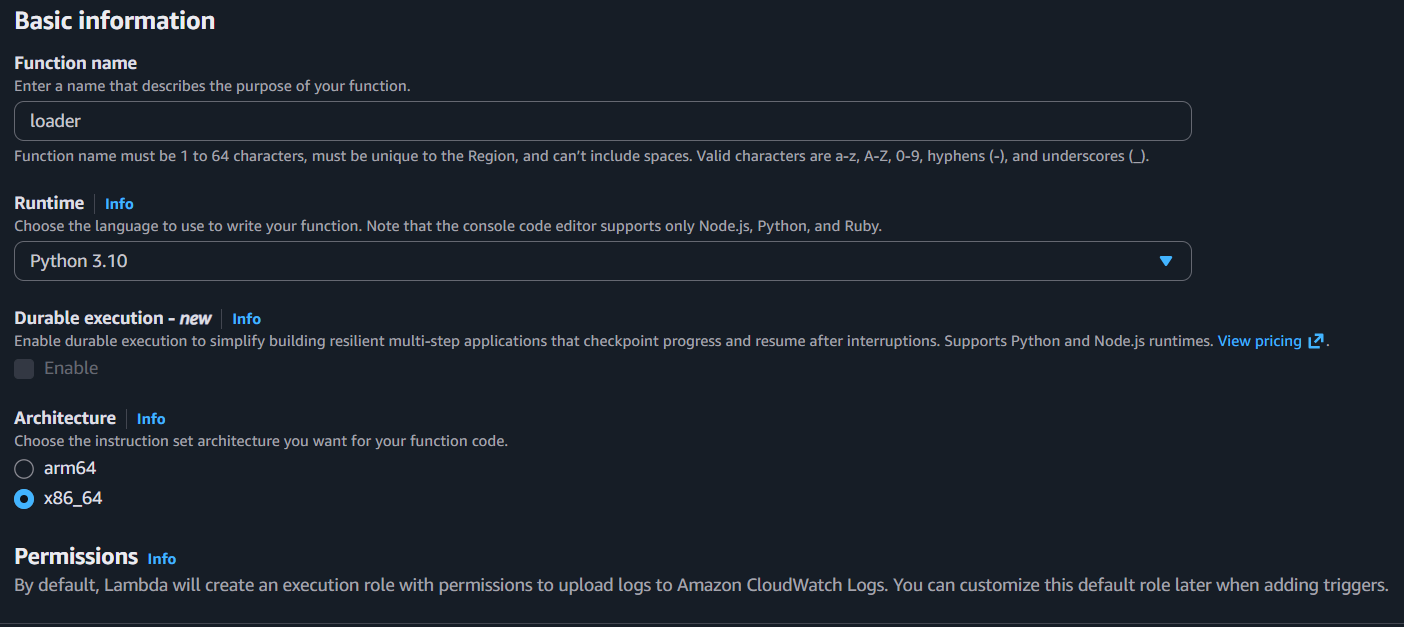

3. Click en **"Create function"**

### **2.3 Subir código**

1. En la sección **"Code source"**
2. Click en **"Upload from"** → **".zip file"**
3. Seleccionar `lambda-loader.zip`
4. Click **"Save"**

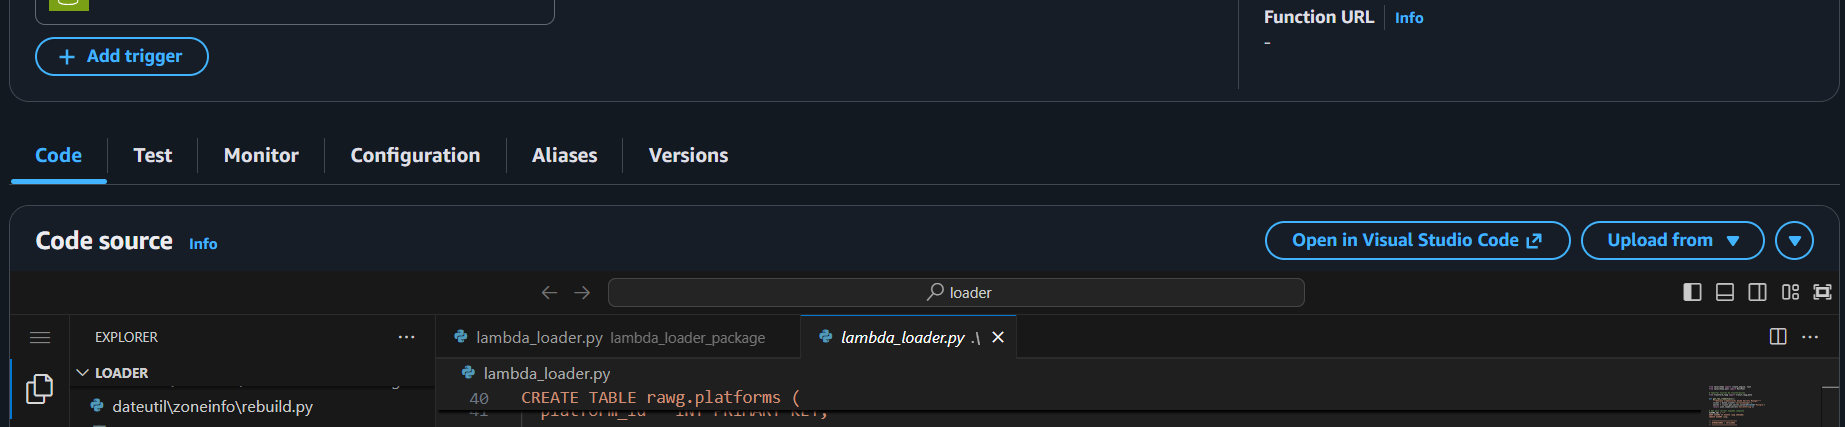

⏳ **Espera:** Lambda descomprime el archivo (~10 segundos)

### **2.4 Configurar Runtime settings**

1. Scroll down hasta **"Runtime settings"**
2. Click **"Edit"**
3. Configurar:

| Campo | Valor |
|-------|-------|
| **Handler** | `lambda_loader.lambda_handler` |

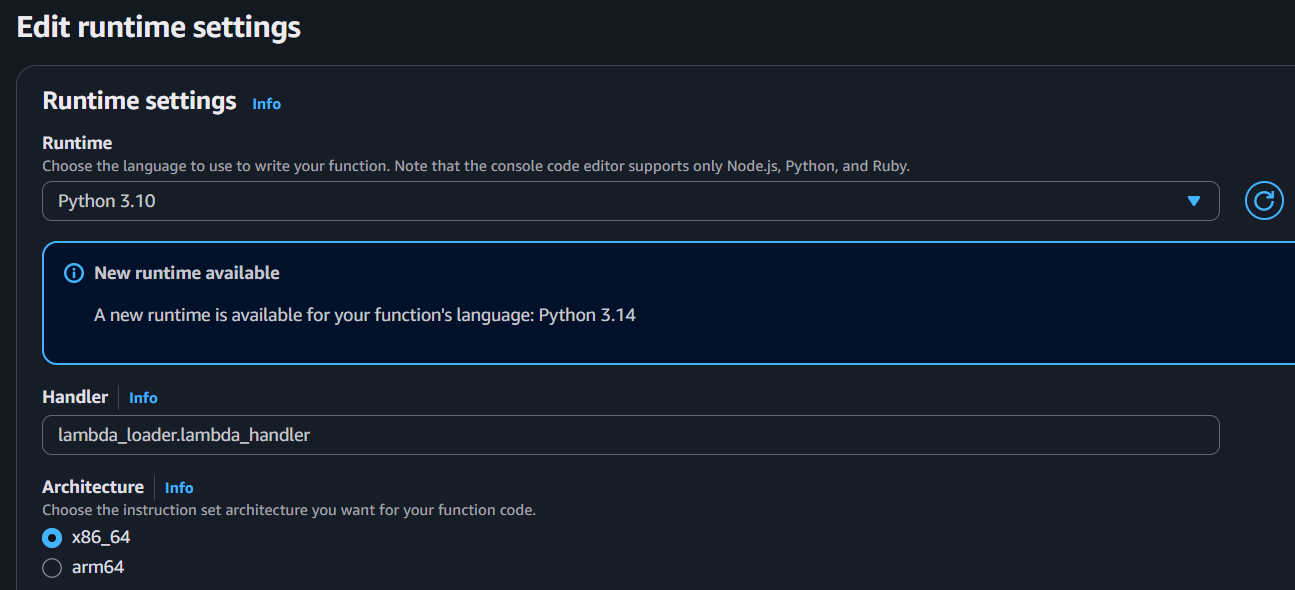

4. Click **"Save"**


### **2.5 Configurar General configuration**

1. Ir a pestaña **"Configuration"** → **"General configuration"**
2. Click **"Edit"**
3. Configurar:

| Campo | Valor | Explicación |
|-------|-------|-------------|
| **Memory** | 1024 MB | Suficiente para procesar datasets grandes |
| **Timeout** | 5 min (300 sec) | Tiempo máximo de ejecución |
| **Ephemeral storage** | 512 MB | Espacio temporal (default OK) |

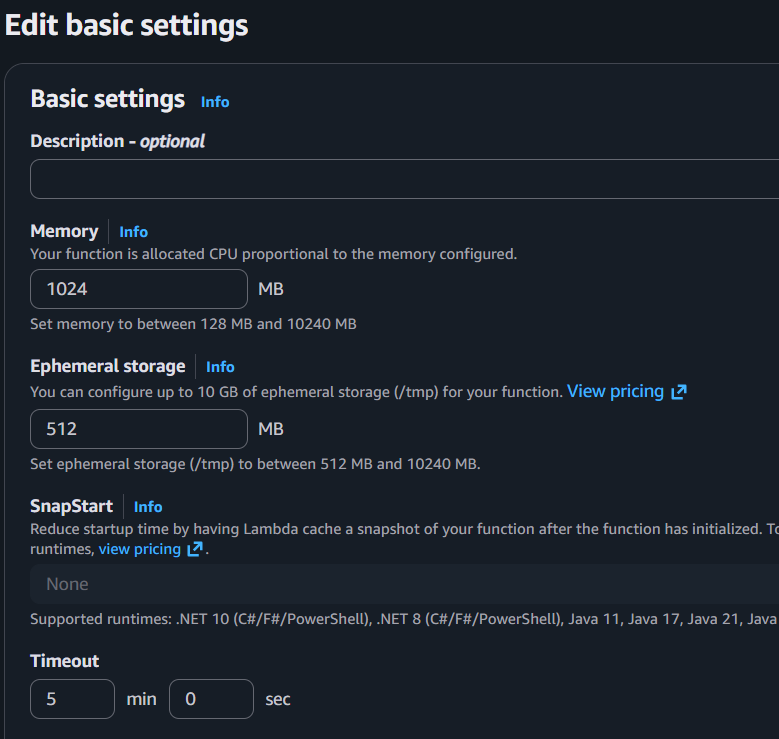

4. Click **"Save"**

## 3. Configurar Lambda Layers

Las Lambda Layers proporcionan las librerías necesarias (pandas, psycopg2, sqlalchemy) sin aumentar el tamaño del código.

###  Añadir Layer de psycopg2**

1. Click **"Add a layer"** nuevamente
2. En la consola creamos carpeta de la librería y comprimimos en .zip
3. Creamos layer en Lambda> Layers subiendo el archivo .zip

 Error reiterado por incompatibilidad de versiones. Posiblemente también por compilar la librería desde Windows  
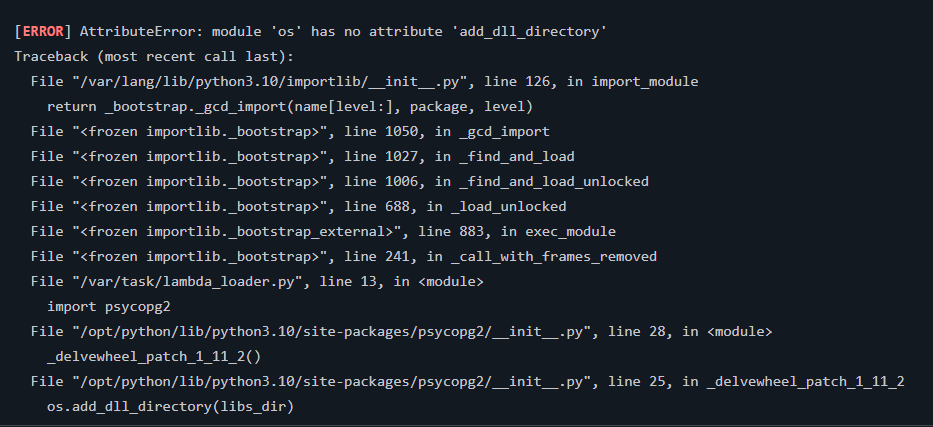

Solución: sustituír librería psycopg2 por código pg8000, incluírlo en lambda-loader.zip y volver a subirlo a la función
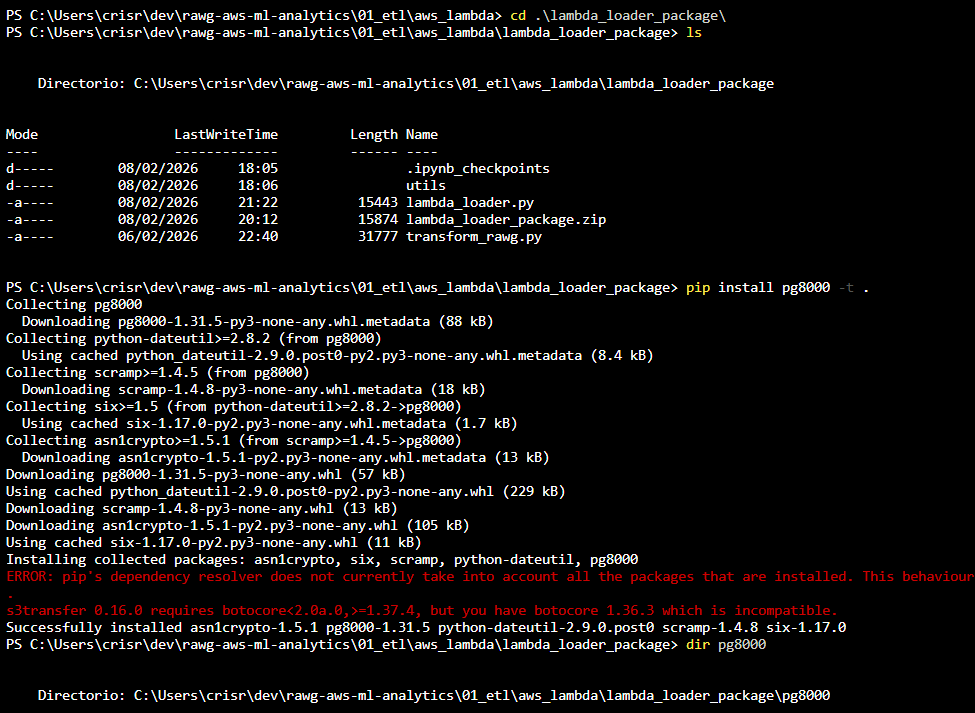

4. Click **"Add"**


### **3.3 Añadir Layer de SQLAlchemy (custom)**

#### **Crear el layer localmente:**

- Crear estructura
mkdir -p sqlalchemy-layer/python/lib/python3.11/site-packages

- Instalar SQLAlchemy
pip install sqlalchemy -t sqlalchemy-layer/python/lib/python3.11/site-packages/

- Crear ZIP
cd sqlalchemy-layer
zip -r ../sqlalchemy-layer.zip python
cd ..

#### **Subir a AWS:**

1. Ir a **Lambda Console** → **Layers** (menú lateral izquierdo)
2. Click **"Create layer"**
3. Configurar:

| Campo | Valor |
|-------|-------|
| **Name** | `sqlalchemy-py310` |
| **Upload** | sqlalchemy-layer.zip |
| **Compatible runtimes** | Python 3.10 |



4. Click **"Create"**


#### **Añadir a la función:**

1. Volver a tu función `loader`
2. **Layers** → **"Add a layer"**
3. Seleccionar **"Custom layers"**
4. Elegir `sqlalchemy-py310`
5. Click **"Add"**


### **3.4 Verificar Layers**

En la sección **Layers** deberías ver:
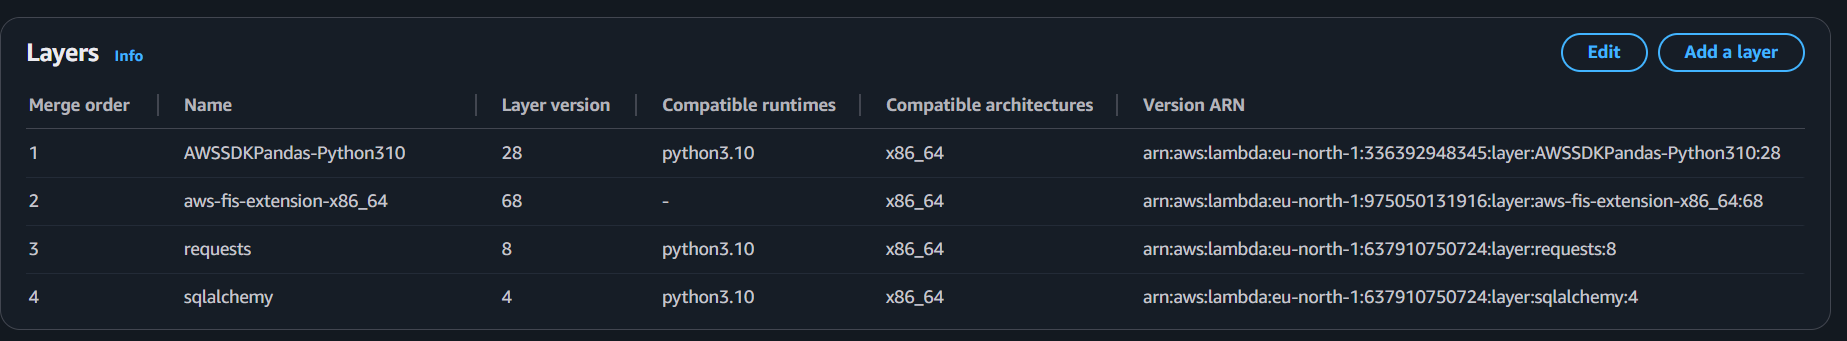

## 4. Añadir trigger S3

### **4.1 Configurar trigger**

1. Click **"Add trigger"**
2. Seleccionar **S3**
3. Configurar:

| Campo | Valor |
|-------|-------|
| **Bucket** | `project-api-load-rawg-cris` |
| **Event type** | All object create events |
| **Prefix** | (dejar vacío) |
| **Suffix** | `.json` |

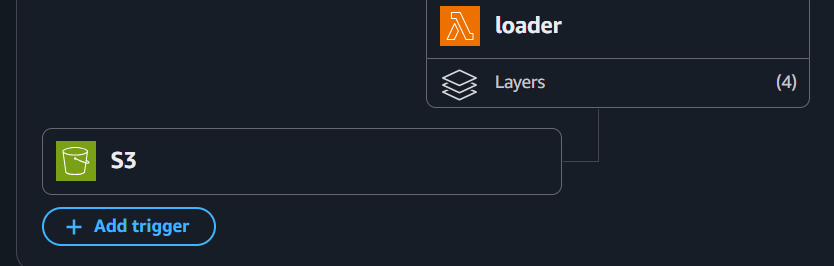

4. ✅ Marcar: **"I acknowledge that using the same S3 bucket..."**
5. Click **"Add"**

---

### **4.2 Verificar trigger**

En el diagrama de la función deberías ver:
```
S3 (project-api-load-rawg-cris) → loader
```





## 🔐 5. Configurar permisos

### **5.1 Añadir permisos al rol de ejecución**

1. Ir a **Configuration** → **Permissions**
2. Click en el **Execution role name**
3. En IAM Console, click **"Add permissions"** → **"Attach policies"**
4. Añadir estas políticas:

| Política | Propósito |
|----------|-----------|
| `AmazonS3ReadOnlyAccess` | Leer archivos de S3 |
| `SecretsManagerReadWrite` | Leer credenciales de RDS |

![IAM Policies](screenshots/12-iam-policies.png)

---

### **5.2 Configurar VPC (si RDS está en VPC privada)**

1. **Configuration** → **VPC**
2. Click **"Edit"**
3. Seleccionar:
   - **VPC:** (tu VPC donde está RDS)
   - **Subnets:** (al menos 2 subnets privadas)
   - **Security groups:** (SG que permite acceso a RDS puerto 5432)

4. Click **"Save"**

⚠️ **Nota:** Esto puede tardar ~1 minuto en aplicarse.


## 🧪 6. Probar la función

### **6.1 Crear evento de prueba**

1. Ir a pestaña **"Test"**
2. Click **"Create new event"**
3. Configurar:

| Campo | Valor |
|-------|-------|
| **Event name** | `test-historico` |
| **Template** | s3-put |

4. Reemplazar el JSON con:
```json
{
  "Records": [
    {
      "s3": {
        "bucket": {
          "name": "project-api-load-rawg-cris"
        },
        "object": {
          "key": "extraccion_historica.json"
        }
      }
    }
  ]
}
```
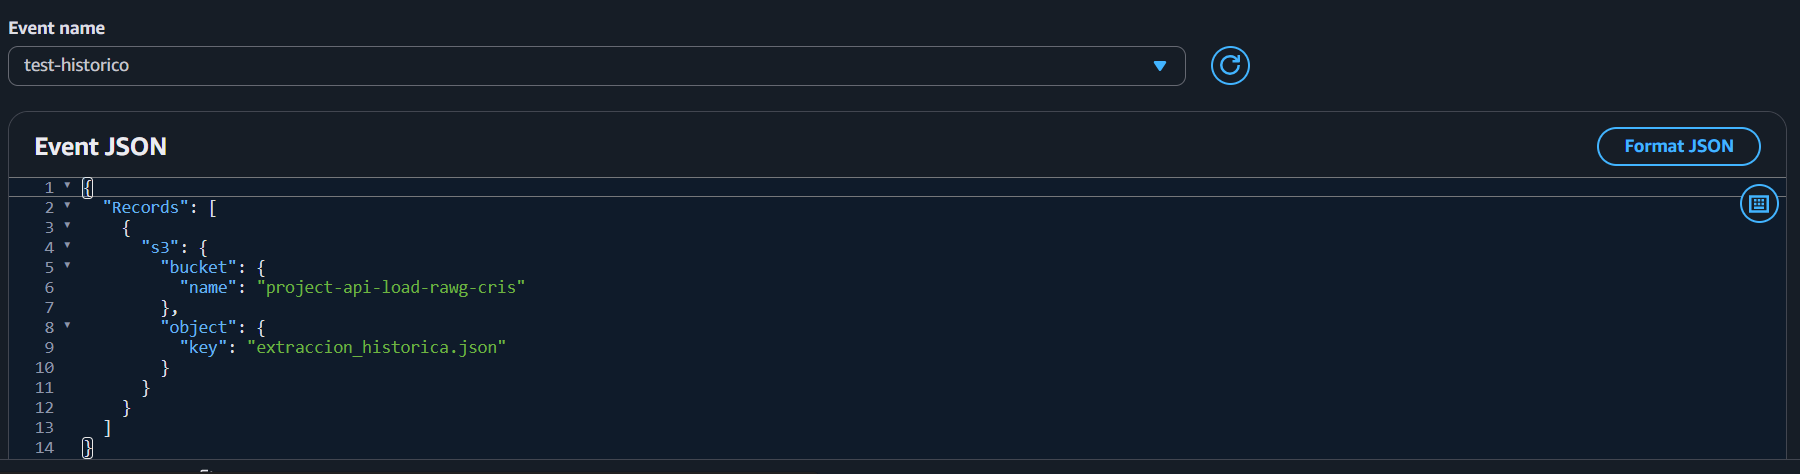


5. Click **"Save"**

### **6.2 Ejecutar test**

![image.png](attachment:4eb1d33b-8566-4492-99ea-c1fb64eae20c.png)

# 🚀 Guía de Deployment - Lambda daily extration (ETL)

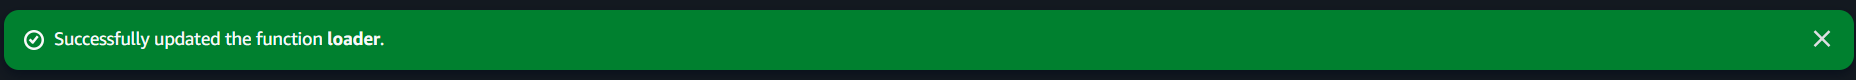

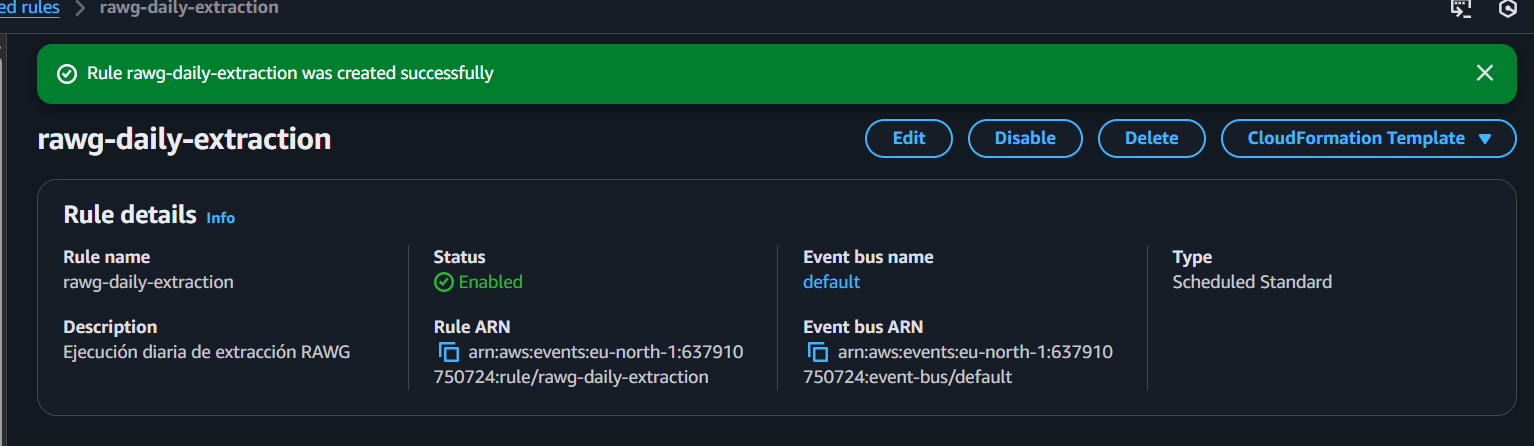

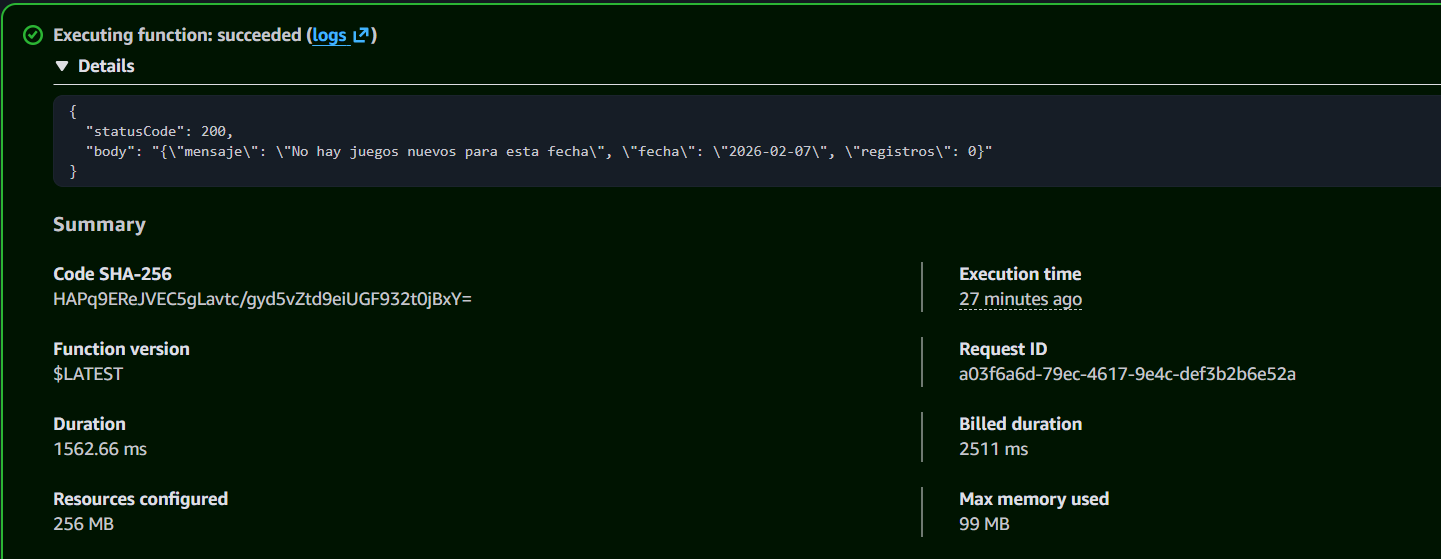

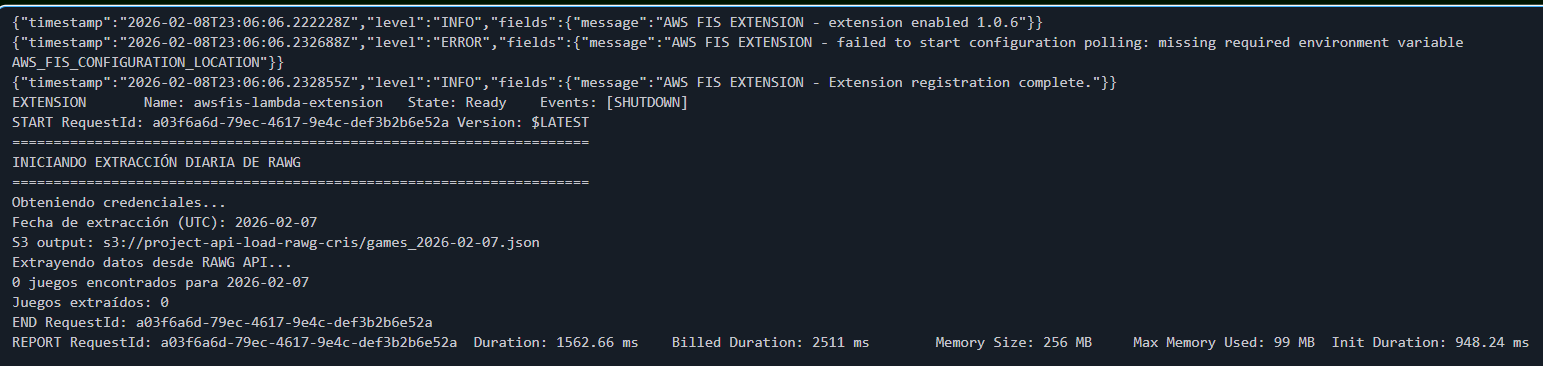